In [1]:
"""
# 02 - Anomaly Detection and Quality Mapping

This notebook uses the slice-wise feature table generated in Notebook 01 to detect anomalous regions along the 3D microCT volume.

The goal is to transform quantitative image features into a simple process-monitoring workflow.

Main steps:

1. Load the feature table.
2. Select relevant features for monitoring.
3. Standardize features.
4. Visualize the feature space using PCA.
5. Detect anomalous slices using Isolation Forest.
6. Assign interpretable anomaly categories.
7. Save anomaly results and figures.
"""

'\n# 02 - Anomaly Detection and Quality Mapping\n\nThis notebook uses the slice-wise feature table generated in Notebook 01 to detect anomalous regions along the 3D microCT volume.\n\nThe goal is to transform quantitative image features into a simple process-monitoring workflow.\n\nMain steps:\n\n1. Load the feature table.\n2. Select relevant features for monitoring.\n3. Standardize features.\n4. Visualize the feature space using PCA.\n5. Detect anomalous slices using Isolation Forest.\n6. Assign interpretable anomaly categories.\n7. Save anomaly results and figures.\n'

In [2]:
# ------------------------------------------------------------
# 02 - Anomaly detection and quality mapping
# ------------------------------------------------------------

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = False

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [3]:
# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------
# This notebook is expected to be inside:
# projects/03_3d_microct_process_monitoring/notebooks/
# ------------------------------------------------------------

NOTEBOOK_DIR = Path.cwd()
CURRENT_PROJECT = NOTEBOOK_DIR.parent

OUTPUTS_DIR = CURRENT_PROJECT / "outputs"
FIGURES_DIR = CURRENT_PROJECT / "figures" / "02_anomaly_detection"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_TABLE_PATH = OUTPUTS_DIR / "features_by_slice.csv"

print("Current project:")
print(CURRENT_PROJECT)

print("\nFeature table:")
print(FEATURE_TABLE_PATH)
print(f"Exists: {FEATURE_TABLE_PATH.exists()}")

print("\nFigures will be saved in:")
print(FIGURES_DIR)

Current project:
C:\Users\Peter\ai-imaging-portfolio\projects\03_3d_microct_process_monitoring

Feature table:
C:\Users\Peter\ai-imaging-portfolio\projects\03_3d_microct_process_monitoring\outputs\features_by_slice.csv
Exists: True

Figures will be saved in:
C:\Users\Peter\ai-imaging-portfolio\projects\03_3d_microct_process_monitoring\figures\02_anomaly_detection


In [4]:
# ------------------------------------------------------------
# Load feature table from Notebook 01
# ------------------------------------------------------------

df = pd.read_csv(FEATURE_TABLE_PATH)

print("Feature table loaded.")
print(f"Shape: {df.shape}")

df.head()

Feature table loaded.
Shape: (435, 22)


,slice_id,z_um,pore_fraction,resin_fraction,matrix_fraction,assigned_fraction,mean_intensity,std_intensity,mean_intensity_pores,mean_intensity_resin,...,mean_pore_area_um2,median_pore_area_um2,mean_pore_equivalent_diameter_um,median_pore_equivalent_diameter_um,resin_object_count,mean_resin_area_um2,median_resin_area_um2,mean_resin_equivalent_diameter_um,median_resin_equivalent_diameter_um,heterogeneity_index
0,0,0.0,0.056875,0.303065,0.622066,0.982006,162.006452,34.223109,76.737897,136.006699,...,52352.000000,19200.0,216.142166,156.352804,592,117805.405405,12800.0,233.533527,127.66153,0.231376
1,1,80.0,0.049366,0.302342,0.638364,0.990071,163.499583,33.344875,77.197183,136.707571,...,45258.964143,12800.0,200.100077,127.661530,769,90473.862159,12800.0,216.507405,127.66153,0.241253
2,2,160.0,0.040800,0.294249,0.657276,0.992324,165.032206,32.662106,77.162236,136.070321,...,35972.413793,12800.0,179.854408,127.661530,755,89684.768212,12800.0,221.468784,127.66153,0.252997
3,3,240.0,0.033513,0.284570,0.673963,0.992046,166.618951,32.181359,77.149378,135.372068,...,30971.887550,12800.0,171.086291,127.661530,704,93018.181818,12800.0,225.478737,127.66153,0.263488
4,4,320.0,0.028952,0.265491,0.697630,0.992074,168.204917,32.126347,77.017291,133.324743,...,25624.615385,12800.0,155.146942,127.661530,672,90914.285714,12800.0,234.745590,127.66153,0.276853


In [5]:
# ------------------------------------------------------------
# Feature selection for anomaly detection
# ------------------------------------------------------------
# We include phase fractions, intensity features, and object-based
# descriptors for both pores and resin.
# ------------------------------------------------------------

monitoring_features = [
    "pore_fraction",
    "resin_fraction",
    "matrix_fraction",
    "mean_intensity",
    "std_intensity",
    "pore_object_count",
    "mean_pore_equivalent_diameter_um",
    "resin_object_count",
    "mean_resin_equivalent_diameter_um",
    "heterogeneity_index",
]

df_monitoring = df[["slice_id", "z_um"] + monitoring_features].copy()

print("Selected monitoring features:")
for col in monitoring_features:
    print(f"- {col}")

df_monitoring.head()

Selected monitoring features:
- pore_fraction
- resin_fraction
- matrix_fraction
- mean_intensity
- std_intensity
- pore_object_count
- mean_pore_equivalent_diameter_um
- resin_object_count
- mean_resin_equivalent_diameter_um
- heterogeneity_index


,slice_id,z_um,pore_fraction,resin_fraction,matrix_fraction,mean_intensity,std_intensity,pore_object_count,mean_pore_equivalent_diameter_um,resin_object_count,mean_resin_equivalent_diameter_um,heterogeneity_index
0,0,0.0,0.056875,0.303065,0.622066,162.006452,34.223109,250,216.142166,592,233.533527,0.231376
1,1,80.0,0.049366,0.302342,0.638364,163.499583,33.344875,251,200.100077,769,216.507405,0.241253
2,2,160.0,0.040800,0.294249,0.657276,165.032206,32.662106,261,179.854408,755,221.468784,0.252997
3,3,240.0,0.033513,0.284570,0.673963,166.618951,32.181359,249,171.086291,704,225.478737,0.263488
4,4,320.0,0.028952,0.265491,0.697630,168.204917,32.126347,260,155.146942,672,234.745590,0.276853


In [6]:
# ------------------------------------------------------------
# Missing value handling
# ------------------------------------------------------------
# NaN values are replaced by the median of each feature.
# This keeps the pipeline simple and robust.
# ------------------------------------------------------------

missing_before = df_monitoring[monitoring_features].isna().sum()

print("Missing values before filling:")
print(missing_before[missing_before > 0])

df_monitoring[monitoring_features] = df_monitoring[monitoring_features].fillna(
    df_monitoring[monitoring_features].median()
)

missing_after = df_monitoring[monitoring_features].isna().sum().sum()

print(f"\nTotal missing values after filling: {missing_after}")

Missing values before filling:
Series([], dtype: int64)

Total missing values after filling: 0


In [7]:
# ------------------------------------------------------------
# Feature standardization
# ------------------------------------------------------------
# Standardization is important because the features have different units:
# - fractions
# - intensities
# - object counts
# - equivalent diameters
# ------------------------------------------------------------

scaler = StandardScaler()

X = df_monitoring[monitoring_features].values
X_scaled = scaler.fit_transform(X)

print("Features standardized.")
print(f"Scaled feature matrix shape: {X_scaled.shape}")

Features standardized.
Scaled feature matrix shape: (435, 10)


In [8]:
# ------------------------------------------------------------
# PCA projection
# ------------------------------------------------------------
# PCA is used here mainly for visualization.
# It helps us see whether some slices occupy unusual regions
# of the feature space.
# ------------------------------------------------------------

pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_scaled)

df_monitoring["PC1"] = X_pca[:, 0]
df_monitoring["PC2"] = X_pca[:, 1]

explained_variance = pca.explained_variance_ratio_

print("PCA completed.")
print(f"Explained variance PC1: {explained_variance[0]:.3f}")
print(f"Explained variance PC2: {explained_variance[1]:.3f}")
print(f"Total explained variance: {explained_variance.sum():.3f}")

PCA completed.
Explained variance PC1: 0.561
Explained variance PC2: 0.236
Total explained variance: 0.797


Figure saved to: C:\Users\Peter\ai-imaging-portfolio\projects\03_3d_microct_process_monitoring\figures\02_anomaly_detection\pca_feature_space_by_depth.png


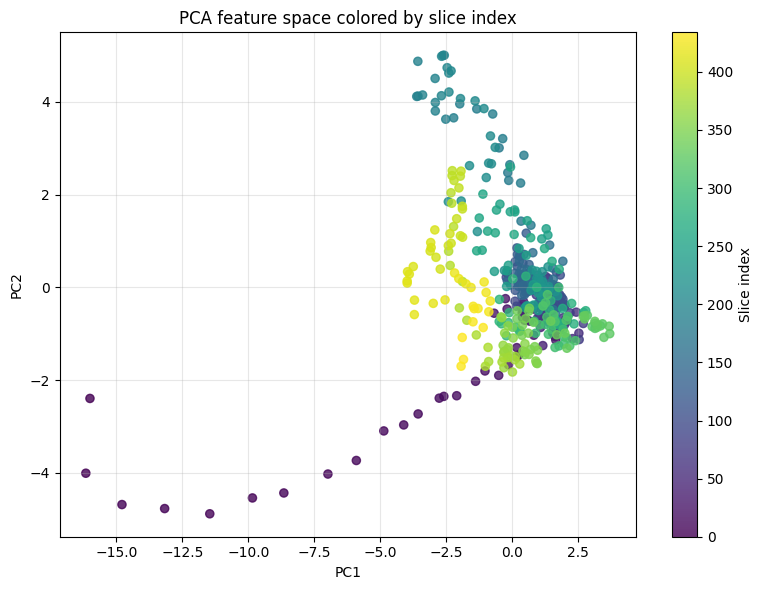

In [9]:
# ------------------------------------------------------------
# PCA feature space colored by slice index
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 6))

scatter = ax.scatter(
    df_monitoring["PC1"],
    df_monitoring["PC2"],
    c=df_monitoring["slice_id"],
    s=35,
    alpha=0.8
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA feature space colored by slice index")
ax.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Slice index")

plt.tight_layout()

fig_path = FIGURES_DIR / "pca_feature_space_by_depth.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"Figure saved to: {fig_path}")

plt.show()

In [31]:
# ------------------------------------------------------------
# Isolation Forest anomaly detection
# ------------------------------------------------------------
# Isolation Forest detects samples that are easier to isolate
# in the multivariate feature space.
#
# contamination controls the expected fraction of anomalous slices.
# ------------------------------------------------------------

CONTAMINATION = 0.05

iso_forest = IsolationForest(
    n_estimators=300,
    contamination=CONTAMINATION,
    random_state=42
)

anomaly_label = iso_forest.fit_predict(X_scaled)

# sklearn returns:
#  1 for normal samples
# -1 for anomalous samples
df_monitoring["is_anomaly"] = anomaly_label == -1

# Higher anomaly_score means more anomalous after sign correction
df_monitoring["anomaly_score"] = -iso_forest.decision_function(X_scaled)

n_anomalies = df_monitoring["is_anomaly"].sum()

print("Isolation Forest completed.")
print(f"Contamination parameter: {CONTAMINATION}")
print(f"Detected anomalous slices: {n_anomalies} / {len(df_monitoring)}")

Isolation Forest completed.
Contamination parameter: 0.05
Detected anomalous slices: 22 / 435


Figure saved to: C:\Users\Peter\ai-imaging-portfolio\projects\03_3d_microct_process_monitoring\figures\02_anomaly_detection\anomaly_score_by_depth.png


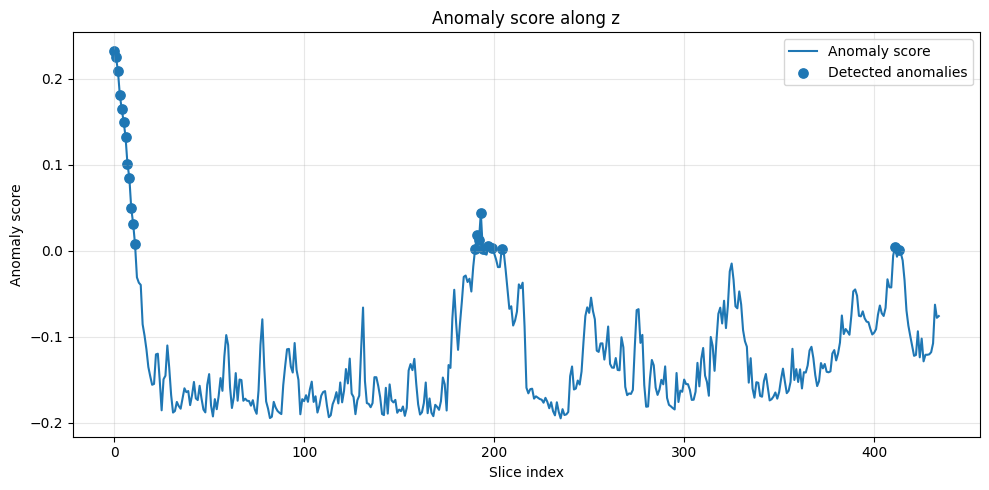

In [32]:
# ------------------------------------------------------------
# Anomaly score along z
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    df_monitoring["slice_id"],
    df_monitoring["anomaly_score"],
    label="Anomaly score"
)

ax.scatter(
    df_monitoring.loc[df_monitoring["is_anomaly"], "slice_id"],
    df_monitoring.loc[df_monitoring["is_anomaly"], "anomaly_score"],
    label="Detected anomalies",
    s=45
)

ax.set_xlabel("Slice index")
ax.set_ylabel("Anomaly score")
ax.set_title("Anomaly score along z")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()

fig_path = FIGURES_DIR / "anomaly_score_by_depth.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"Figure saved to: {fig_path}")

plt.show()

Figure saved to: C:\Users\Peter\ai-imaging-portfolio\projects\03_3d_microct_process_monitoring\figures\02_anomaly_detection\pca_anomaly_map.png


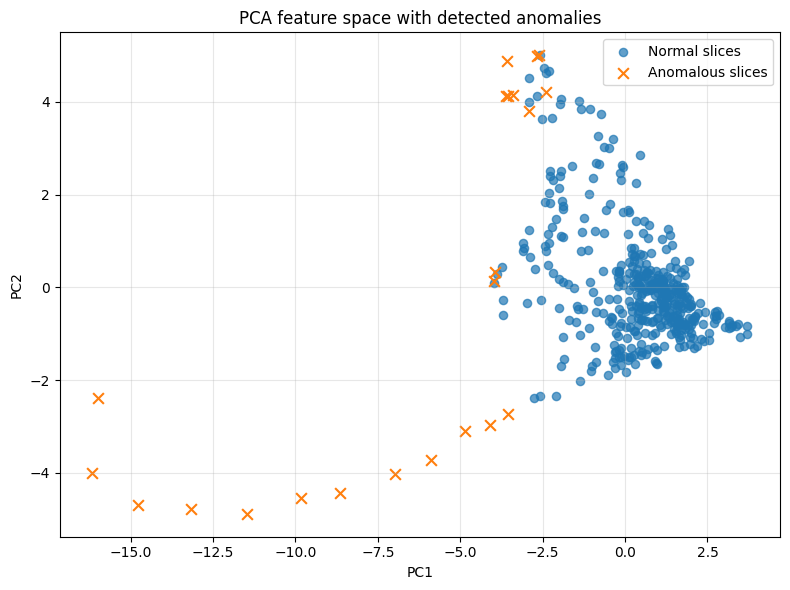

In [33]:
# ------------------------------------------------------------
# PCA space with detected anomalies
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 6))

normal = ~df_monitoring["is_anomaly"]
anomalous = df_monitoring["is_anomaly"]

ax.scatter(
    df_monitoring.loc[normal, "PC1"],
    df_monitoring.loc[normal, "PC2"],
    label="Normal slices",
    s=35,
    alpha=0.7
)

ax.scatter(
    df_monitoring.loc[anomalous, "PC1"],
    df_monitoring.loc[anomalous, "PC2"],
    label="Anomalous slices",
    s=60,
    marker="x"
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("PCA feature space with detected anomalies")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()

fig_path = FIGURES_DIR / "pca_anomaly_map.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"Figure saved to: {fig_path}")

plt.show()

In [34]:
# ------------------------------------------------------------
# Interpretable anomaly categories
# ------------------------------------------------------------
# We assign simple rule-based labels to anomalous slices.
#
# This is not a supervised classifier.
# It is an interpretable post-processing step based on feature deviations.
# ------------------------------------------------------------

def assign_anomaly_category(row, reference_stats):
    """
    Assign an interpretable category to an anomalous slice
    based on which features are unusually high or low.
    """

    if not row["is_anomaly"]:
        return "normal"

    categories = []

    # Reference thresholds based on quartiles
    if row["pore_fraction"] > reference_stats.loc["q75", "pore_fraction"]:
        categories.append("high_porosity")

    if row["resin_fraction"] > reference_stats.loc["q75", "resin_fraction"]:
        categories.append("resin_rich")

    if row["resin_object_count"] > reference_stats.loc["q75", "resin_object_count"]:
        categories.append("resin_fragmented")

    if row["mean_pore_equivalent_diameter_um"] > reference_stats.loc["q75", "mean_pore_equivalent_diameter_um"]:
        categories.append("large_pores")

    if row["heterogeneity_index"] > reference_stats.loc["q75", "heterogeneity_index"]:
        categories.append("heterogeneous")

    if len(categories) == 0:
        categories.append("multivariate_anomaly")

    return "+".join(categories)


# Compute robust reference thresholds
reference_stats = pd.DataFrame({
    "q25": df_monitoring[monitoring_features].quantile(0.25),
    "q50": df_monitoring[monitoring_features].quantile(0.50),
    "q75": df_monitoring[monitoring_features].quantile(0.75),
}).T

df_monitoring["anomaly_category"] = df_monitoring.apply(
    assign_anomaly_category,
    axis=1,
    reference_stats=reference_stats
)

df_monitoring["anomaly_category"].value_counts()

anomaly_category
normal                                                   413
high_porosity+resin_rich+resin_fragmented                  6
high_porosity+resin_fragmented+large_pores                 5
resin_rich+resin_fragmented                                4
high_porosity+resin_rich+resin_fragmented+large_pores      3
high_porosity+large_pores                                  2
high_porosity+resin_rich+large_pores                       1
high_porosity+resin_rich                                   1
Name: count, dtype: int64

In [35]:
# ------------------------------------------------------------
# Inspect anomalous slices
# ------------------------------------------------------------

anomaly_columns = [
    "slice_id",
    "z_um",
    "anomaly_score",
    "anomaly_category",
    "pore_fraction",
    "resin_fraction",
    "matrix_fraction",
    "pore_object_count",
    "mean_pore_equivalent_diameter_um",
    "resin_object_count",
    "mean_resin_equivalent_diameter_um",
    "heterogeneity_index",
]

df_anomalies = df_monitoring.loc[
    df_monitoring["is_anomaly"],
    anomaly_columns
].sort_values("anomaly_score", ascending=False)

print(f"Number of anomalous slices: {len(df_anomalies)}")

df_anomalies.head(15)

Number of anomalous slices: 22


,slice_id,z_um,anomaly_score,anomaly_category,pore_fraction,resin_fraction,matrix_fraction,pore_object_count,mean_pore_equivalent_diameter_um,resin_object_count,mean_resin_equivalent_diameter_um,heterogeneity_index
0,0,0.0,0.232357,high_porosity+resin_rich+resin_fragmented+larg...,0.056875,0.303065,0.622066,250,216.142166,592,233.533527,0.231376
1,1,80.0,0.224484,high_porosity+resin_rich+resin_fragmented+larg...,0.049366,0.302342,0.638364,251,200.100077,769,216.507405,0.241253
2,2,160.0,0.208778,high_porosity+resin_rich+resin_fragmented+larg...,0.040800,0.294249,0.657276,261,179.854408,755,221.468784,0.252997
3,3,240.0,0.180866,high_porosity+resin_rich+resin_fragmented,0.033513,0.284570,0.673963,249,171.086291,704,225.478737,0.263488
4,4,320.0,0.164346,high_porosity+resin_rich+resin_fragmented,0.028952,0.265491,0.697630,260,155.146942,672,234.745590,0.276853
5,5,400.0,0.150086,high_porosity+resin_rich+resin_fragmented,0.025503,0.254450,0.712760,270,147.004028,576,249.696527,0.285732
6,6,480.0,0.132312,high_porosity+resin_rich+resin_fragmented,0.022528,0.244605,0.724663,296,136.096873,512,266.952241,0.293024
7,7,560.0,0.101083,high_porosity+resin_rich+resin_fragmented,0.017966,0.238708,0.735399,272,126.234806,427,291.458833,0.300025
8,8,640.0,0.084839,resin_rich+resin_fragmented,0.013266,0.241629,0.737958,224,119.896477,396,318.460417,0.302521
9,9,720.0,0.049300,resin_rich+resin_fragmented,0.011987,0.239932,0.741935,190,122.735789,352,345.872693,0.304921


Figure saved to: C:\Users\Peter\ai-imaging-portfolio\projects\03_3d_microct_process_monitoring\figures\02_anomaly_detection\anomaly_category_summary.png


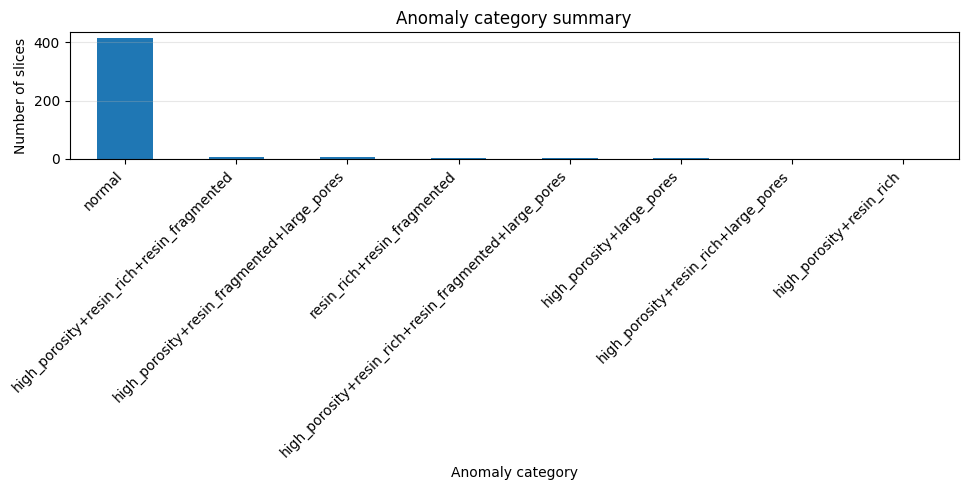

In [36]:
# ------------------------------------------------------------
# Anomaly category summary
# ------------------------------------------------------------

category_counts = df_monitoring["anomaly_category"].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))

category_counts.plot(kind="bar", ax=ax)

ax.set_xlabel("Anomaly category")
ax.set_ylabel("Number of slices")
ax.set_title("Anomaly category summary")
ax.grid(True, axis="y", alpha=0.3)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

fig_path = FIGURES_DIR / "anomaly_category_summary.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"Figure saved to: {fig_path}")

plt.show()

In [37]:
# ------------------------------------------------------------
# Feature comparison: normal vs anomalous slices
# ------------------------------------------------------------

comparison_features = [
    "pore_fraction",
    "resin_fraction",
    "pore_object_count",
    "mean_pore_equivalent_diameter_um",
    "resin_object_count",
    "mean_resin_equivalent_diameter_um",
    "heterogeneity_index",
]

summary_normal = df_monitoring.loc[~df_monitoring["is_anomaly"], comparison_features].mean()
summary_anomaly = df_monitoring.loc[df_monitoring["is_anomaly"], comparison_features].mean()

comparison_df = pd.DataFrame({
    "normal_mean": summary_normal,
    "anomaly_mean": summary_anomaly
})

comparison_df["relative_change"] = (
    comparison_df["anomaly_mean"] - comparison_df["normal_mean"]
) / (comparison_df["normal_mean"].abs() + 1e-8)

comparison_df

,normal_mean,anomaly_mean,relative_change
pore_fraction,0.011217,0.033222,1.961835
resin_fraction,0.202967,0.238134,0.173265
pore_object_count,64.184019,158.818182,1.474419
mean_pore_equivalent_diameter_um,158.094168,183.116516,0.158275
resin_object_count,245.615012,408.681818,0.663912
mean_resin_equivalent_diameter_um,422.470599,339.265814,-0.196948
heterogeneity_index,0.327668,0.289907,-0.115240


Figure saved to: C:\Users\Peter\ai-imaging-portfolio\projects\03_3d_microct_process_monitoring\figures\02_anomaly_detection\feature_contribution_summary.png


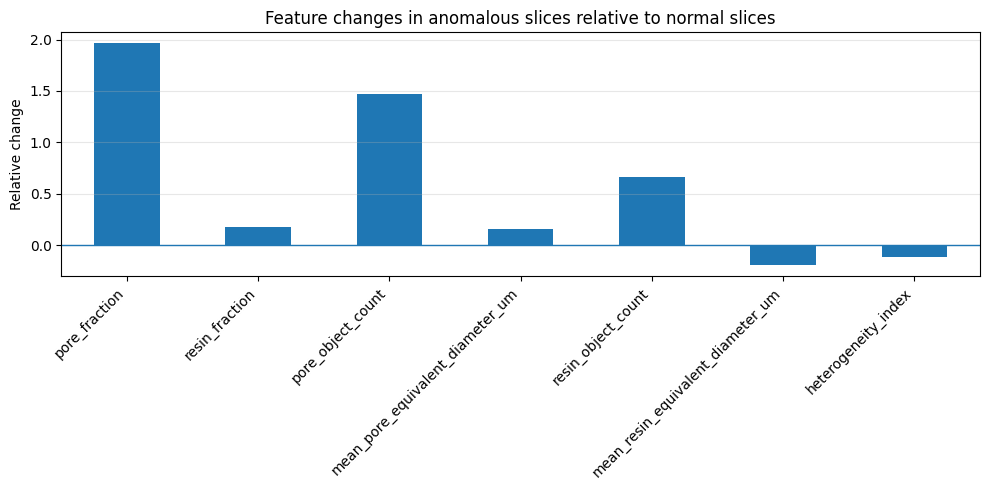

In [38]:
# ------------------------------------------------------------
# Relative feature change in anomalous slices
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

comparison_df["relative_change"].plot(kind="bar", ax=ax)

ax.axhline(0, linewidth=1)

ax.set_ylabel("Relative change")
ax.set_title("Feature changes in anomalous slices relative to normal slices")
ax.grid(True, axis="y", alpha=0.3)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

fig_path = FIGURES_DIR / "feature_contribution_summary.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"Figure saved to: {fig_path}")

plt.show()

In [39]:
# ------------------------------------------------------------
# Save anomaly detection results
# ------------------------------------------------------------

anomaly_results_path = OUTPUTS_DIR / "anomaly_results.csv"

df_monitoring.to_csv(anomaly_results_path, index=False)

print("Anomaly results saved to:")
print(anomaly_results_path)

Anomaly results saved to:
C:\Users\Peter\ai-imaging-portfolio\projects\03_3d_microct_process_monitoring\outputs\anomaly_results.csv


In [40]:
# ------------------------------------------------------------
# Final summary
# ------------------------------------------------------------

print("Notebook 02 completed successfully.")

print("\nGenerated output table:")
print(f"- {anomaly_results_path}")

print("\nGenerated figures:")
for file in sorted(FIGURES_DIR.glob("*.png")):
    print(f"- {file.name}")

print("\nDetected anomaly categories:")
print(df_monitoring["anomaly_category"].value_counts())

Notebook 02 completed successfully.

Generated output table:
- C:\Users\Peter\ai-imaging-portfolio\projects\03_3d_microct_process_monitoring\outputs\anomaly_results.csv

Generated figures:
- anomaly_category_summary.png
- anomaly_score_by_depth.png
- feature_contribution_summary.png
- pca_anomaly_map.png
- pca_feature_space_by_depth.png

Detected anomaly categories:
anomaly_category
normal                                                   413
high_porosity+resin_rich+resin_fragmented                  6
high_porosity+resin_fragmented+large_pores                 5
resin_rich+resin_fragmented                                4
high_porosity+resin_rich+resin_fragmented+large_pores      3
high_porosity+large_pores                                  2
high_porosity+resin_rich+large_pores                       1
high_porosity+resin_rich                                   1
Name: count, dtype: int64
